# Chapter 2: Aromaticity and Resonance

## 1. Introduction

This section explores aromaticity, a fundamental concept in medicinal chemistry that profoundly influences a compound's behavior. Aromaticity and resonance are two fundamental concepts that govern the stability, reactivity, and properties of organic molecules. In drug discovery, approximately 80% of approved drugs contain at least one aromatic ring. Understanding these concepts is essential for predicting molecular behavior, designing stable drug candidates, and interpreting structure-activity relationships.

---

## 2. Key Concepts and Definitions

*   **π (pi) Electrons**: Electrons in p-orbitals that overlap sideways to form π bonds above and below the plane of the molecule.
*   **Electron Delocalization**: The spreading of electron density across multiple atoms rather than being confined between two atoms.
*   **Resonance**: Individual Lewis structures that differ only in electron placement (not atom positions). The actual molecule is a weighted average of all resonance contributors.
*   **Aromaticity**: Aromaticity: Exceptional stability arising from cyclic delocalization of π electrons following Hückel's rule (4n+2 π electrons).

---

## 3. Main Content

### 3.1 Understanding Resonance

In 1865, Friedrich Kekulé proposed a structure for benzene (C₆H₆) with alternating single and double bonds. However, this structure created a puzzle: 

* Bond length uniformity: X-ray crystallography shows all six C-C bonds are 1.39 Å—exactly between a single bond (1.54 Å) and double bond (1.34 Å).
  
* Unusual stability: If benzene had three isolated double bonds, we'd expect certain reactions. Instead, benzene is remarkably unreactive to addition reactions that alkenes readily undergo.


![Different representations of benzene](images/2_3_resonance_structure.png)

The answer lies in understanding how electrons are actually distributed in benzene.

In reality, each carbon atom contributes one electron in its p-orbital. With 6 carbons, that's 6 electrons that can be delocalized in the ring.

**The mechanism of delocalization:**

* **p-Orbital overlap**: The six p-orbitals (one from each carbon) are all parallel and can overlap with their neighbors.
* **Continuous π system**: As the p-orbitals overlap around the entire ring, this creates a continuous electron cloud. We call this the **π system**
* **Electron cloud formation**: The 6 π electrons occupy molecular orbitals that extend over all six carbons—above and below the ring plane like two donuts.
* **Energy lowering**: This delocalization lowers the energy of the system, making benzene more stable than expected. This extra stability is called resonance energy or delocalization energy (~36 kcal/mol for benzene).

In [1]:
import py3Dmol
from rdkit import Chem
from rdkit.Chem import AllChem
import numpy as np
from IPython.display import display, HTML

# --- 1. Math Helper Functions ---

def get_ring_data(mol):
    """Calculates geometry vectors for the benzene ring."""
    conf = mol.GetConformer()
    positions = [np.array(conf.GetAtomPosition(i)) for i in range(6)]
    centroid = np.mean(positions, axis=0)
    
    # Calculate Normal Vector
    v1 = positions[2] - positions[0]
    v2 = positions[4] - positions[0]
    normal = np.cross(v1, v2)
    normal = normal / np.linalg.norm(normal)
    
    return positions, centroid, normal

# --- 2. Drawing Logic ---

def draw_comparison():
    # A. Prepare Molecule
    mol = Chem.MolFromSmiles('c1ccccc1')
    mol = Chem.AddHs(mol)
    AllChem.EmbedMolecule(mol)
    AllChem.MMFFOptimizeMolecule(mol)
    mol_block = Chem.MolToMolBlock(mol)
    
    positions, centroid, normal = get_ring_data(mol)

    # B. Initialize Viewer with Grid (1 Row, 2 Columns)
    view = py3Dmol.view(width=760, height=760, viewergrid=(1,2), linked=False)
    
    # --- SHARED STYLING FUNCTION (UPDATED) ---
    # We now use the style from your second code block:
    # radius 0.2 and 'darkCarbon' colorscheme.
    def style_molecule(viewer_coords):
        view.addModel(mol_block, 'mol', viewer=viewer_coords)
        view.setStyle({'stick': {'radius': 0.2, 'colorscheme': 'darkCarbon'}}, viewer=viewer_coords)

    # --- LEFT PANEL: Atomic Orbitals (Grid 0,0) ---
    style_molecule((0,0))
    
    # Add Labels
    view.addLabel("Individual Atomic p-Orbitals", 
                  {'position': {'x':0, 'y':-3.5, 'z':0}, 'backgroundColor': '#eee', 'fontColor': 'black'},
                  viewer=(0,0))

    # Draw 6 isolated Lobes
    orbital_offset = 0.6
    
    # Unified Color and Alpha settings
    col_top = '#ff6b6b'
    col_bot = '#4dabf7'
    alpha_val = 0.6  # Set same intensity for both sides

    for pos in positions:
        top = pos + (normal * orbital_offset)
        bot = pos - (normal * orbital_offset)
        
        # Top (Red)
        view.addSphere({'center': {'x': top[0], 'y': top[1], 'z': top[2]},
                        'radius': 0.35, 'color': col_top, 'alpha': alpha_val}, viewer=(0,0))
        # Bottom (Blue)
        view.addSphere({'center': {'x': bot[0], 'y': bot[1], 'z': bot[2]},
                        'radius': 0.35, 'color': col_bot, 'alpha': alpha_val}, viewer=(0,0))

    # --- RIGHT PANEL: Resonance Cloud (Grid 0,1) ---
    style_molecule((0,1))

    view.addLabel("Delocalized \u03C0-System", 
                  {'position': {'x':0, 'y':-3.5, 'z':0}, 'backgroundColor': '#eee', 'fontColor': 'black'},
                  viewer=(0,1))

    # Draw Cloud (Torus)
    arbitrary = np.array([1, 0, 0]) if normal[0] < 0.9 else np.array([0, 1, 0])
    tangent1 = np.cross(normal, arbitrary)
    tangent1 = tangent1 / np.linalg.norm(tangent1)
    tangent2 = np.cross(normal, tangent1)
    
    radius = 1.4
    steps = 50 
    cloud_height = 0.5
    
    for i in range(steps):
        angle = (2 * np.pi / steps) * i
        # Point on the ring circle
        ring_point = centroid + (radius * np.cos(angle) * tangent1) + \
                                (radius * np.sin(angle) * tangent2)
        
        top_cloud = ring_point + (normal * cloud_height)
        bot_cloud = ring_point - (normal * cloud_height)
        
        # Overlapping spheres using the SAME colors and alpha as the left side
        view.addSphere({'center': {'x': top_cloud[0], 'y': top_cloud[1], 'z': top_cloud[2]},
                        'radius': 0.45, 'color': col_top, 'alpha': alpha_val}, viewer=(0,1))
        view.addSphere({'center': {'x': bot_cloud[0], 'y': bot_cloud[1], 'z': bot_cloud[2]},
                        'radius': 0.45, 'color': col_bot, 'alpha': alpha_val}, viewer=(0,1))

    # Final Polish
    view.zoomTo()
    view.setBackgroundColor('white')
    
    return view

# --- 3. Display ---
view = draw_comparison()
view.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

The phenomenon where **electrons are delocalized** is known as **resonance**. 

### 3.2 Aromaticity

Now that we understand benzene's electron delocalization (resonance), we can extend to the concept of **aromaticity**. 

Aromaticity is the **special stability** that arises when:

* **A cyclic system**
The molecule must form a closed ring to create a continuous loop for electron delocalization. Without a ring, electrons cannot circulate completely around the system, preventing the formation of the stabilizing aromatic electron cloud.

In [2]:
import py3Dmol
from rdkit import Chem
from rdkit.Chem import AllChem
import numpy as np
from IPython.display import display, HTML

# --- Helper: Molecule Generation ---
def get_mol_geometry(smiles):
    mol = Chem.MolFromSmiles(smiles)
    mol = Chem.AddHs(mol)
    # ETKDGv3 is robust for ring systems and chains
    params = AllChem.ETKDGv3() 
    params.randomSeed = 0xf00d 
    AllChem.EmbedMolecule(mol, params)
    AllChem.MMFFOptimizeMolecule(mol)
    return mol, Chem.MolToMolBlock(mol)

# --- Helper: Base Viewer Setup ---
def init_comparison_viewer(width=760, height=760):
    view = py3Dmol.view(width=width, height=height, viewergrid=(1,2), linked=False)
    return view

def style_standard(view, mol_block, coordinates, title):
    view.addModel(mol_block, 'mol', viewer=coordinates)
    # Increased radius from 0.15 to 0.2 for "fuller" looking bonds
    view.setStyle({'stick': {'radius': 0.2, 'colorscheme': 'darkCarbon'}}, viewer=coordinates)
    view.addLabel(title, {'position': {'x':0, 'y':-4, 'z':0}, 'backgroundColor': '#eee', 'fontColor': 'black'}, viewer=coordinates)
    view.zoomTo(viewer=coordinates)

def visualize_criterion_cyclic():
    view = init_comparison_viewer()

    # 1. PASS: Benzene
    mol_pass, block_pass = get_mol_geometry('c1ccccc1')
    style_standard(view, block_pass, (0,0), "Benzene (Cyclic)")

    # 2. FAIL: Hexatriene (Acyclic)
    # Changed SMILES to explicit trans-isomer (C=C/C=C/C=C) 
    # This ensures the chain is extended flat so bonds are clearly shown
    mol_fail, block_fail = get_mol_geometry('C=C/C=C/C=C') 
    style_standard(view, block_fail, (0,1), "Hexatriene (Acyclic)")
    
    # (Red sphere styling removed)

    return view

view1 = visualize_criterion_cyclic()
view1.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

* **Contains a fully conjugated π system (continuous overlap) that exhibits *resonance***

Every atom in the ring must have a p-orbital that overlaps with its neighbors without interruption, creating an unbroken "highway" for π electrons to delocalize. If even one atom lacks a p-orbital (like sp³ hybridized carbons in cyclohexane), the conjugation is broken and aromaticity is lo

In [6]:
import py3Dmol
from rdkit import Chem
from rdkit.Chem import AllChem
import numpy as np

# --- 1. Helper: Geometry & Normals ---
def get_mol_geometry(smiles):
    mol = Chem.MolFromSmiles(smiles)
    mol = Chem.AddHs(mol)
    # Use ETKDG for initial embedding, then MMFF for physical optimization
    AllChem.EmbedMolecule(mol, AllChem.ETKDG()) 
    AllChem.MMFFOptimizeMolecule(mol)
    return mol, Chem.MolToMolBlock(mol)

def get_local_normal(mol, atom_idx):
    """Calculates a local normal vector for a specific atom based on neighbors."""
    conf = mol.GetConformer()
    origin = np.array(conf.GetAtomPosition(atom_idx))
    
    neighbors = [np.array(conf.GetAtomPosition(n.GetIdx())) for n in mol.GetAtomWithIdx(atom_idx).GetNeighbors()]
    
    if len(neighbors) < 2: return np.array([0,1,0]) 
    
    v1 = neighbors[0] - origin
    v2 = neighbors[1] - origin
    
    normal = np.cross(v1, v2)
    norm = np.linalg.norm(normal)
    return normal / norm if norm > 0 else np.array([0,1,0])

# --- 2. Drawing Functions (Electron Clouds) ---

def draw_continuous_ring_cloud(view, mol, viewer_coords):
    """Draws the continuous Benzene Torus."""
    conf = mol.GetConformer()
    positions = [np.array(conf.GetAtomPosition(i)) for i in range(6)]
    centroid = np.mean(positions, axis=0)
    
    # Calculate ring normal
    v1 = positions[2] - positions[0]
    v2 = positions[4] - positions[0]
    normal = np.cross(v1, v2)
    normal = normal / np.linalg.norm(normal)

    # Cloud geometry setup
    arbitrary = np.array([1, 0, 0]) if normal[0] < 0.9 else np.array([0, 1, 0])
    tangent1 = np.cross(normal, arbitrary)
    tangent1 = tangent1 / np.linalg.norm(tangent1)
    tangent2 = np.cross(normal, tangent1)
    
    radius = 1.4
    steps = 60
    cloud_height = 0.5
    col_top = '#ff6b6b' # Red (Top phase)
    col_bot = '#4dabf7' # Blue (Bottom phase)
    
    for i in range(steps):
        angle = (2 * np.pi / steps) * i
        ring_point = centroid + (radius * np.cos(angle) * tangent1) + \
                                (radius * np.sin(angle) * tangent2)
        
        top = ring_point + (normal * cloud_height)
        bot = ring_point - (normal * cloud_height)
        
        view.addSphere({'center': {'x':top[0], 'y':top[1], 'z':top[2]}, 'radius': 0.4, 'color': col_top, 'alpha': 0.6}, viewer=viewer_coords)
        view.addSphere({'center': {'x':bot[0], 'y':bot[1], 'z':bot[2]}, 'radius': 0.4, 'color': col_bot, 'alpha': 0.6}, viewer=viewer_coords)

def draw_localized_pi_bonds(view, mol, viewer_coords):
    """Draws tubes ONLY over the double bonds."""
    conf = mol.GetConformer()
    
    for bond in mol.GetBonds():
        if bond.GetBondType() == Chem.BondType.DOUBLE:
            idx_a = bond.GetBeginAtomIdx()
            idx_b = bond.GetEndAtomIdx()
            
            pos_a = np.array(conf.GetAtomPosition(idx_a))
            pos_b = np.array(conf.GetAtomPosition(idx_b))
            
            norm_a = get_local_normal(mol, idx_a)
            norm_b = get_local_normal(mol, idx_b)
            avg_normal = (norm_a + norm_b) / 2
            avg_normal = avg_normal / np.linalg.norm(avg_normal)
            
            steps = 15
            cloud_height = 0.6
            
            for t in np.linspace(0, 1, steps):
                current_pos = pos_a + t * (pos_b - pos_a)
                
                top = current_pos + (avg_normal * cloud_height)
                bot = current_pos - (avg_normal * cloud_height)
                
                view.addSphere({'center': {'x':top[0], 'y':top[1], 'z':top[2]}, 'radius': 0.35, 'color': '#ff6b6b', 'alpha': 0.6}, viewer=viewer_coords)
                view.addSphere({'center': {'x':bot[0], 'y':bot[1], 'z':bot[2]}, 'radius': 0.35, 'color': '#4dabf7', 'alpha': 0.6}, viewer=viewer_coords)

# --- 3. Main Visualization (Clean Style) ---

def visualize_conjugation_clean():
    view = py3Dmol.view(width=760, height=760, viewergrid=(1,2), linked=False)
    
    # --- LEFT: BENZENE ---
    mol_ben, block_ben = get_mol_geometry('c1ccccc1')
    view.addModel(block_ben, 'mol', viewer=(0,0))
    
    # STYLE: Standard Stick (Elemental Coloring)
    view.setStyle({'stick': {}}, viewer=(0,0))
    
    # Label
    view.addLabel("Benzene (Delocalized pi e)", 
                  {'position': {'x':0, 'y':-3.5, 'z':0}, 
                   'backgroundColor': 'white', 
                   'fontColor': 'black',
                   'borderWidth': 1,
                   'borderColor': '#ccc'}, viewer=(0,0))
    
    draw_continuous_ring_cloud(view, mol_ben, (0,0))

    # --- RIGHT: 1,4-CYCLOHEXADIENE ---
    mol_diene, block_diene = get_mol_geometry('C1=CCC=CC1')
    view.addModel(block_diene, 'mol', viewer=(0,1))
    
    # STYLE: Standard Stick (Elemental Coloring)
    view.setStyle({'stick': {}}, viewer=(0,1))
    
    # Label
    view.addLabel("Cyclohexadiene (Localized pi e)", 
                  {'position': {'x':0, 'y':-3.5, 'z':0}, 
                   'backgroundColor': 'white', 
                   'fontColor': 'black',
                   'borderWidth': 1,
                   'borderColor': '#ccc'}, viewer=(0,1))

    draw_localized_pi_bonds(view, mol_diene, (0,1))

    view.zoomTo()
    return view

view = visualize_conjugation_clean()
view.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

* **Has a planar geometry** (to allow p-orbital overlap)
All atoms in the ring must lie in the same plane so their p-orbitals can align parallel to each other and overlap effectively above and below the ring. If the ring is puckered or twisted, the p-orbitals point in different directions and cannot overlap properly, breaking the conjugation.

In [3]:
import py3Dmol
from rdkit import Chem
from rdkit.Chem import AllChem

# --- 1. Geometry Generator with Physics Optimization ---
def get_mol_geometry(smiles):
    mol = Chem.MolFromSmiles(smiles)
    mol = Chem.AddHs(mol)
    
    # Generate initial 3D coordinates
    AllChem.EmbedMolecule(mol, AllChem.ETKDG())
    
    # CRITICAL STEP: Force Field Optimization
    # This simulates physical forces. It detects the steric strain in COT
    # and twists it into the "Tub" shape to relieve energy.
    AllChem.MMFFOptimizeMolecule(mol)
    
    block = Chem.MolToMolBlock(mol)
    return mol, block

# --- 2. Viewer Helper Functions ---
def init_comparison_viewer():
    # Creates a 1 row x 2 column grid
    view = py3Dmol.view(width=760, height=760, viewergrid=(1,2), linked=False)
    return view

def style_standard(view, mol_block, grid_pos, title):
    view.addModel(mol_block, 'mol', viewer=grid_pos)
    # Use 'stick' style for better visibility of angles
    view.setStyle({'stick': {}}, viewer=grid_pos)
    view.addLabel(title, {'position': {'x':0, 'y':-4, 'z':0}, 
                          'backgroundColor': 'white', 
                          'fontColor': 'black'}, viewer=grid_pos)
    view.zoomTo(viewer=grid_pos)

# --- 3. Main Visualization Logic ---
def visualize_criterion_planar():
    view = init_comparison_viewer()

    # --- LEFT PANEL: Benzene (PASS) ---
    mol_pass, block_pass = get_mol_geometry('c1ccccc1')
    style_standard(view, block_pass, (0,0), "Benzene (Planar)")
    
    # Box is a thin 'Wall' (XY Plane) to match RDKit orientation
    # w=6, h=6, d=0.1 (depth is the thin dimension)
    view.addBox({'center':{'x':0,'y':0,'z':0}, 
                 'dimensions': {'w':6, 'h':6, 'd':0.1}, 
                 'color':'#ccf2ff', 'opacity':0.5}, viewer=(0,0))

    # --- RIGHT PANEL: Cyclooctatetraene (FAIL) ---
    mol_fail, block_fail = get_mol_geometry('C1=CC=CC=CC=C1')
    style_standard(view, block_fail, (0,1), "Cyclooctatetraene (Tub Shape)")

    # Box is a thin 'Wall' (XY Plane)
    # w=7, h=7, d=0.1
    view.addBox({'center':{'x':0,'y':0,'z':0}, 
                 'dimensions': {'w':7, 'h':7, 'd':0.1}, 
                 'color':'#ffcccc', 'opacity':0.5}, viewer=(0,1))

    return view

# --- 4. Execution ---
view2 = visualize_criterion_planar()
view2.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

* Follows **Hückel's rule**: 4n+2 π electrons (where n = 0, 1, 2, 3...)

The system must contain a specific "magic number" of π electrons that completely fills all bonding molecular orbitals. This creates maximum stabilization.

| Molecule | π Electrons | n Value | 4n or 4n+2? | Classification |
|----------|-------------|---------|-------------|----------------|
| Benzene | 6 | 1 | 4n + 2 | Aromatic ✅ |
| Cyclopentadienyl anion | 6 | 1 | 4n + 2 | Aromatic ✅ |
| Tropylium cation | 6 | 1 | 4n + 2 | Aromatic ✅ |
| Naphthalene | 10 | 2 | 4n + 2 | Aromatic ✅ |
| Pyridine | 6 | 1 | 4n + 2 | Aromatic ✅ |
| Cyclobutadiene | 4 | 1 | 4n | Anti-aromatic ❌ |
| Cyclooctatetraene | 8 | 2 | 4n | Non-aromatic ❌ |
| Cyclopentadiene | 4 | - | - | Non-aromatic ❌ |

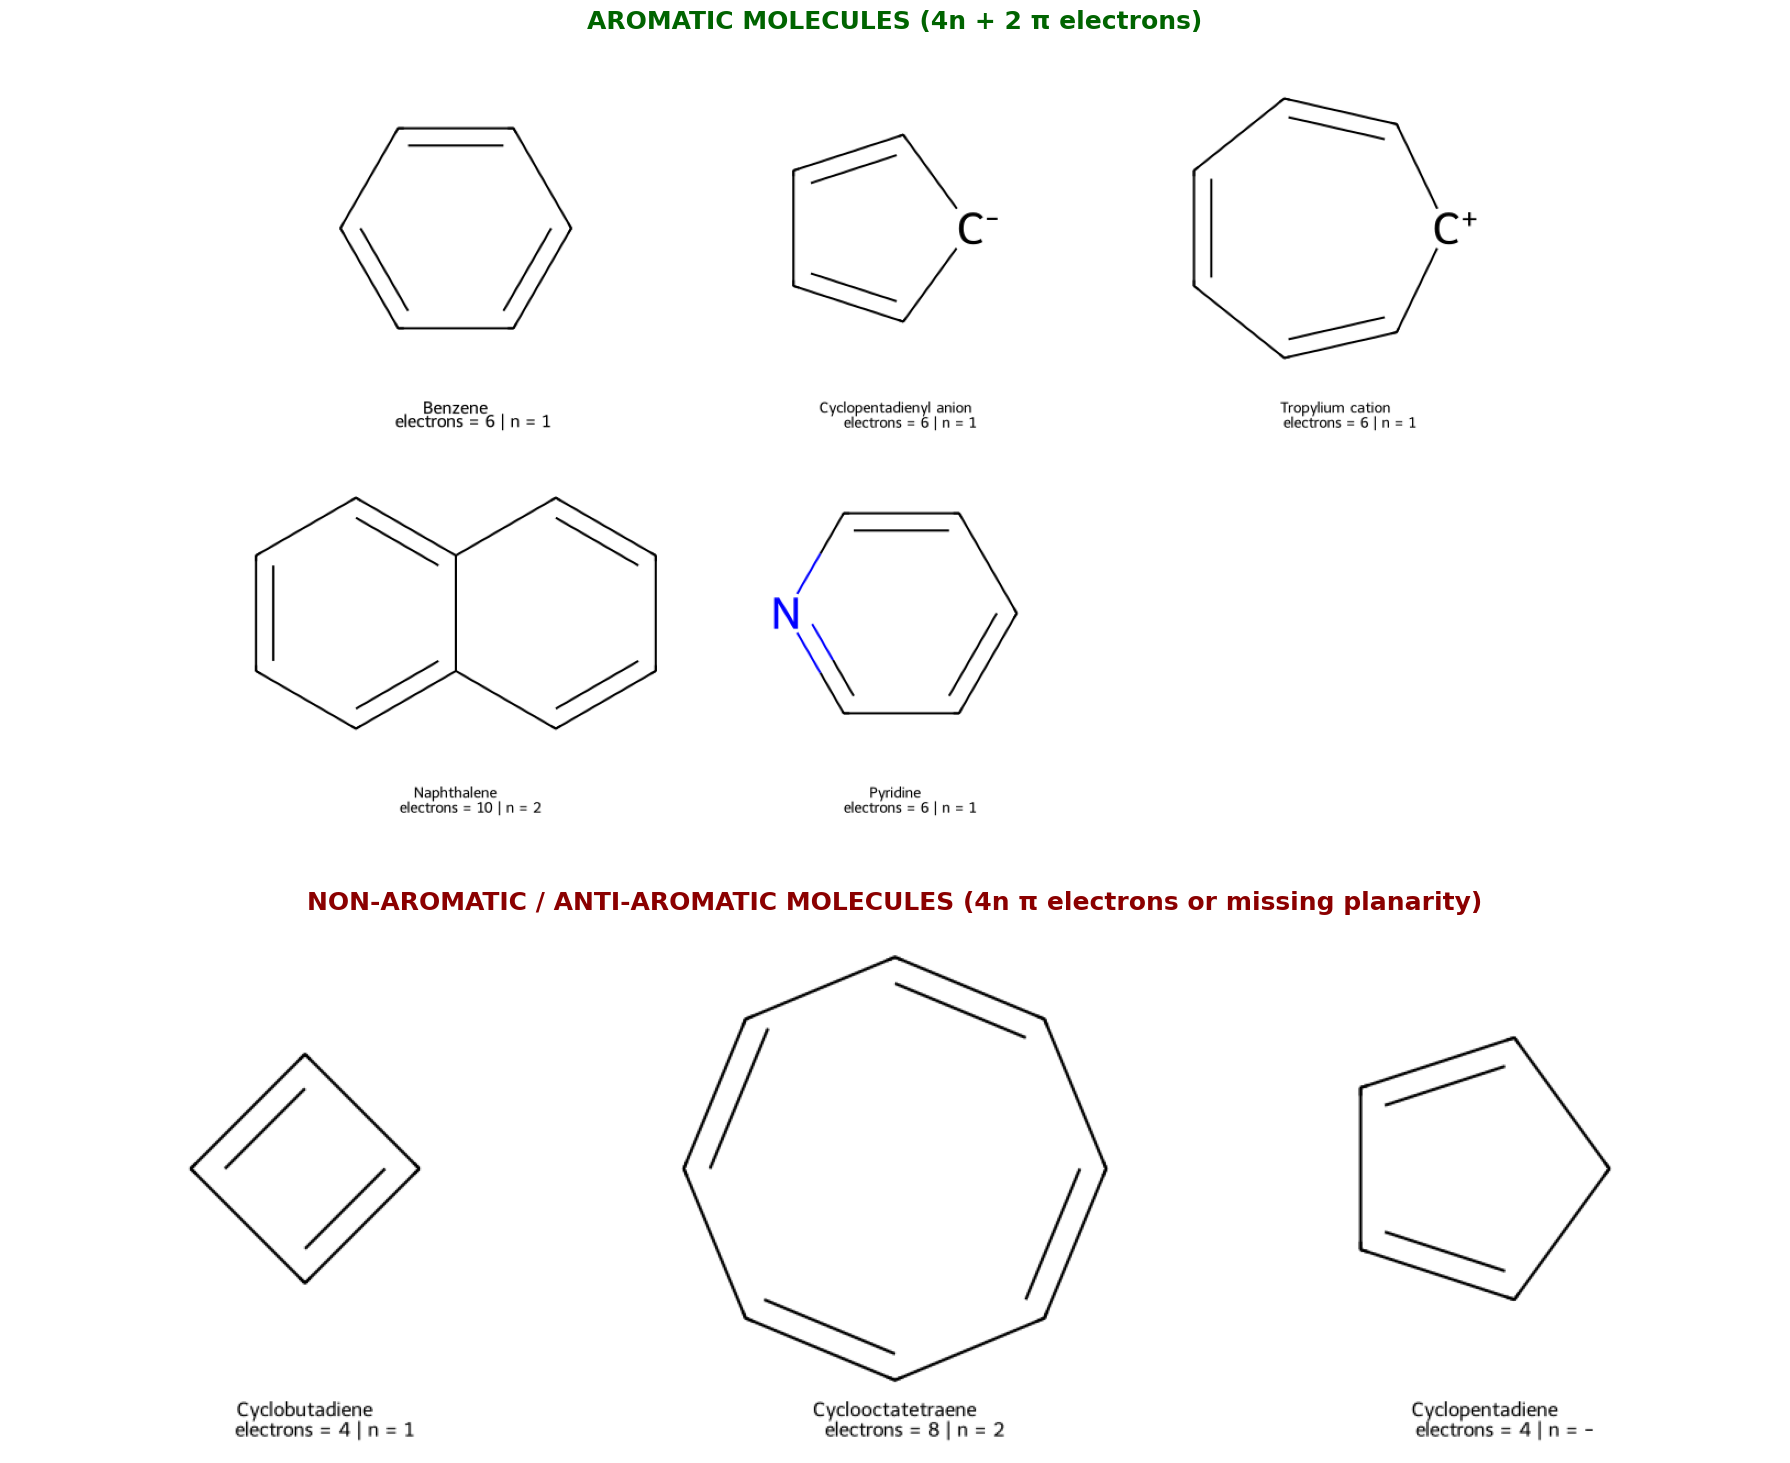

In [10]:
"""
Draw molecules for Hückel's rule aromaticity examples using RDKit
For Jupyter Lab - displays inline
"""
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem import AllChem
import matplotlib.pyplot as plt
from IPython.display import display

# Define molecules with their properties
molecules_data = [
    {
        "name": "Benzene",
        "smiles": "c1ccccc1",
        "pi_electrons": 6,
        "n_value": 1,
        "rule": "4n + 2",
        "classification": "Aromatic"
    },
    {
        "name": "Cyclopentadienyl anion",
        "smiles": "[CH-]1C=CC=C1",
        "pi_electrons": 6,
        "n_value": 1,
        "rule": "4n + 2",
        "classification": "Aromatic"
    },
    {
        "name": "Tropylium cation",
        "smiles": "[cH+]1cccccc1",
        "pi_electrons": 6,
        "n_value": 1,
        "rule": "4n + 2",
        "classification": "Aromatic"
    },
    {
        "name": "Naphthalene",
        "smiles": "c1ccc2ccccc2c1",
        "pi_electrons": 10,
        "n_value": 2,
        "rule": "4n + 2",
        "classification": "Aromatic"
    },
    {
        "name": "Pyridine",
        "smiles": "c1ccncc1",
        "pi_electrons": 6,
        "n_value": 1,
        "rule": "4n + 2",
        "classification": "Aromatic"
    },
    {
        "name": "Cyclobutadiene",
        "smiles": "C1=CC=C1",
        "pi_electrons": 4,
        "n_value": 1,
        "rule": "4n",
        "classification": "Anti-aromatic"
    },
    {
        "name": "Cyclooctatetraene",
        "smiles": "C1=CC=CC=CC=C1",
        "pi_electrons": 8,
        "n_value": 2,
        "rule": "4n",
        "classification": "Non-aromatic"
    },
    {
        "name": "Cyclopentadiene",
        "smiles": "C1C=CC=C1",
        "pi_electrons": 4,
        "n_value": "-",
        "rule": "-",
        "classification": "Non-aromatic"
    }
]

# Create molecule objects
mols = []
legends = []
for mol_data in molecules_data:
    mol = Chem.MolFromSmiles(mol_data["smiles"])
    if mol is not None:
        AllChem.Compute2DCoords(mol)
        mols.append(mol)
    else:
        print(f"Failed to create molecule: {mol_data['name']}")

# Create vertical layout with aromatic on top
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 16))

# Aromatic molecules (top panel)
aromatic_mols = [mol for mol, data in zip(mols, molecules_data) if data['classification'] == "Aromatic"]
aromatic_legends = [f"{data['name']}\nπ electrons = {data['pi_electrons']} | n = {data['n_value']}" 
                    for mol, data in zip(mols, molecules_data) if data['classification'] == "Aromatic"]

if aromatic_mols:
    img_aromatic = Draw.MolsToGridImage(
        aromatic_mols,
        molsPerRow=3,
        subImgSize=(400, 350),
        legends=aromatic_legends,
        returnPNG=False,
        useSVG=False
    )
    ax1.imshow(img_aromatic)
    ax1.set_title("AROMATIC MOLECULES (4n + 2 π electrons)", 
                  fontsize=18, fontweight='bold', color='darkgreen', pad=20)
    ax1.axis('off')

# Non-aromatic/Anti-aromatic molecules (bottom panel)
non_aromatic_mols = [mol for mol, data in zip(mols, molecules_data) if data['classification'] != "Aromatic"]
non_aromatic_legends = [f"{data['name']}\nπ electrons = {data['pi_electrons']} | n = {data['n_value']}" 
                        for mol, data in zip(mols, molecules_data) if data['classification'] != "Aromatic"]

if non_aromatic_mols:
    img_non_aromatic = Draw.MolsToGridImage(
        non_aromatic_mols,
        molsPerRow=3,
        subImgSize=(400, 350),
        legends=non_aromatic_legends,
        returnPNG=False,
        useSVG=False
    )
    ax2.imshow(img_non_aromatic)
    ax2.set_title("NON-AROMATIC / ANTI-AROMATIC MOLECULES (4n π electrons or missing planarity)", 
                  fontsize=18, fontweight='bold', color='darkred', pad=20)
    ax2.axis('off')

plt.tight_layout()
plt.show()

In [5]:
import py3Dmol
from rdkit import Chem
from rdkit.Chem import AllChem
import numpy as np

def get_mol_geometry(smiles):
    """
    Helper to convert SMILES to a 3D embedded molecule block.
    """
    mol = Chem.MolFromSmiles(smiles)
    mol = Chem.AddHs(mol) # Add hydrogens for proper 3D structure
    # Generate 3D Conformer
    AllChem.EmbedMolecule(mol, AllChem.ETKDG()) 
    # Generate the MolBlock string required by py3Dmol
    block = Chem.MolToMolBlock(mol)
    return mol, block

def visualize_criterion_huckel():
    # Initialize viewer with a 1x2 Grid
    view = py3Dmol.view(width=760, height=400, viewergrid=(1, 2), linked=False)
    
    def draw_pi_cloud(mol, viewer_coords, color_top, color_bot):
        conf = mol.GetConformer()
        # Get positions of Carbon atoms only
        positions = [conf.GetAtomPosition(i) for i in range(mol.GetNumAtoms()) 
                     if mol.GetAtomWithIdx(i).GetSymbol() == 'C']
        
        for pos in positions:
            # Drawing vague spheres to represent p-orbitals/pi-system
            # Note: This simple offset assumes the molecule is relatively flat on the XY plane
            view.addSphere({
                'center': {'x': pos.x, 'y': pos.y, 'z': pos.z + 0.5},
                'radius': 0.6, 
                'color': color_top, 
                'alpha': 0.6
            }, viewer=viewer_coords)
            
            view.addSphere({
                'center': {'x': pos.x, 'y': pos.y, 'z': pos.z - 0.5},
                'radius': 0.6, 
                'color': color_bot, 
                'alpha': 0.6
            }, viewer=viewer_coords)

    # --- 1. PASS: Benzene (6 Electrons) ---
    # Benzene is Aromatic (4n + 2 where n=1)
    mol_pass, block_pass = get_mol_geometry('c1ccccc1')
    
    # Add to Left Panel (0,0)
    view.addModel(block_pass, 'sdf', viewer=(0,0))
    view.setStyle({'stick': {}}, viewer=(0,0)) # Standard Style
    view.addLabel("Benzene: 6 pi e- (Aromatic)", 
                  {'position': {'x':0, 'y':-3, 'z':0}, 'backgroundColor': 'white', 'fontColor': 'black'}, 
                  viewer=(0,0))
    
    draw_pi_cloud(mol_pass, (0,0), '#51cf66', '#51cf66') # Green = Stable

    # --- 2. FAIL: Cyclobutadiene (4 Electrons) ---
    # Cyclobutadiene is Anti-Aromatic (4n where n=1)
    mol_fail, block_fail = get_mol_geometry('C1=CC=C1')
    
    # Add to Right Panel (0,1)
    view.addModel(block_fail, 'sdf', viewer=(0,1))
    view.setStyle({'stick': {}}, viewer=(0,1)) # Standard Style
    view.addLabel("Cyclobutadiene: 4 pi e- (Anti-Aromatic)", 
                  {'position': {'x':0, 'y':-3, 'z':0}, 'backgroundColor': 'white', 'fontColor': 'black'}, 
                  viewer=(0,1))
    
    draw_pi_cloud(mol_fail, (0,1), '#ff6b6b', '#ff6b6b') # Red = Unstable

    # Final settings
    view.zoomTo() # Ensure camera is focused on the molecules
    return view

view4 = visualize_criterion_huckel()
view4.show()

3Dmol.js failed to load for some reason. Please check your browser console for error messages.

---

## 4. Summary and Key Takeaways

In this section, we've explored the concept of aromaticity and its critical role in drug design and function. We learned to identify aromatic systems using Hückel's rule.

*    Benzene's six π electrons are not localized between carbon pairs but spread continuously across all six carbons through overlapping p-orbitals. This phenomenon is called **resonance**
*   **Aromaticity** is a special type of cyclic resonance requiring four criteria: (1) cyclic structure, (2) planar geometry, (3) fully conjugated π system, and (4) 4n+2 π electrons (Hückel's rule). When all criteria are met, the molecule gains exceptional stability

Understanding aromaticity is essential for interpreting how a molecule binds to its target and how it will be processed by the body. 